# Carbon Footprint Analysis & Estimation Dashboard
### Green Internship Project - Personal Carbon Footprint Prediction & Recommendation System

This notebook presents a comprehensive data science approach to analyzing carbon emissions and estimating individual carbon footprints. Our target is the **Carbon Emission (kg CO2e)**.

#### Project Goals:
1. **Exploratory Data Analysis (EDA)**: Understand the key drivers of personal carbon emissions (e.g., diet, travel, transportation, heating).
2. **Data Cleaning & Handling**: Manage missing values logically (e.g., `Vehicle Type` is dependent on the `Transport` type).
3. **Machine Learning Modeling**: Train multiple regression models (Linear Regression, Random Forest, HistGradientBoosting) to predict emissions.
4. **Model Comparison**: Evaluate model accuracy and find the best predictive algorithm.
5. **Feature Importance Analysis**: Determine which daily activities contribute most to carbon footprints.
6. **Carbon Footprint Calculator**: Provide a reusable Python tool that estimates a user's carbon footprint based on daily habits and provides personalized action items to reduce emissions.


## 1. Environment Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv("Carbon Emission.csv")
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()


Dataset Loaded Successfully! Shape: (10000, 20)


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


## 2. Data Inspection and Cleaning
Let's inspect the data types, missing values, and structure of the dataset.


In [2]:
# Missing value count
print("=== Missing Values ===")
print(df.isna().sum())

print("\n=== Data Info ===")
df.info()


=== Missing Values ===
Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------       

### Handling Logical Missing Values
Notice that `Vehicle Type` has **6,721 missing values**. Let's examine if this is because those individuals do not own a private vehicle. We look at the correlation between `Transport` and missingness in `Vehicle Type`.


In [3]:
# Print missingness of Vehicle Type grouped by Transport mode
print("Missing Vehicle Type counts by Transport mode:")
print(df.groupby('Transport', dropna=False)['Vehicle Type'].apply(lambda x: x.isnull().sum()))

# Fill missing Vehicle Types with 'none' (since public transport / walk/bicycle do not have private vehicle types)
df['Vehicle Type'] = df['Vehicle Type'].fillna('none')

# Verify no missing values remain
print("\nRemaining missing values:")
print(df.isna().sum().sum())


Missing Vehicle Type counts by Transport mode:
Transport
private            0
public          3294
walk/bicycle    3427
Name: Vehicle Type, dtype: int64

Remaining missing values:
0


## 3. Exploratory Data Analysis & Visualization
Let's visualize the distribution of carbon emissions and find out what factors are most strongly correlated with it.


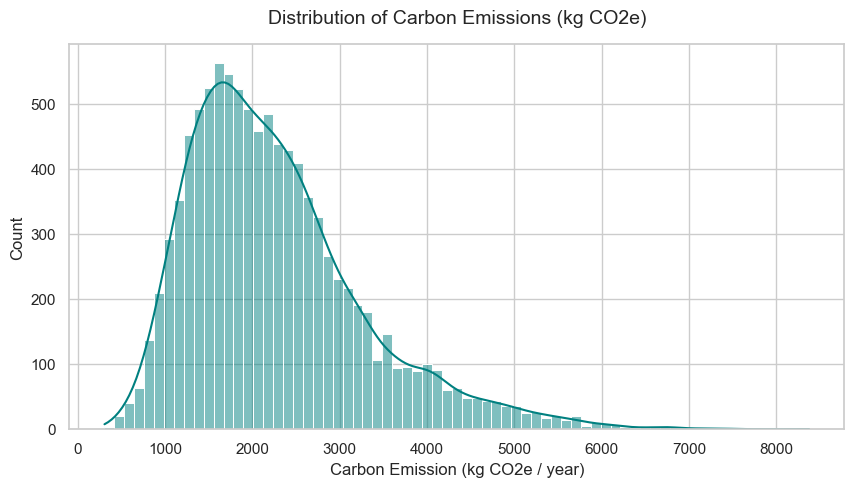

In [4]:
# 1. Distribution of Carbon Emissions
plt.figure(figsize=(10, 5))
sns.histplot(df['CarbonEmission'], kde=True, color='teal')
plt.title('Distribution of Carbon Emissions (kg CO2e)', fontsize=14, pad=15)
plt.xlabel('Carbon Emission (kg CO2e / year)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()


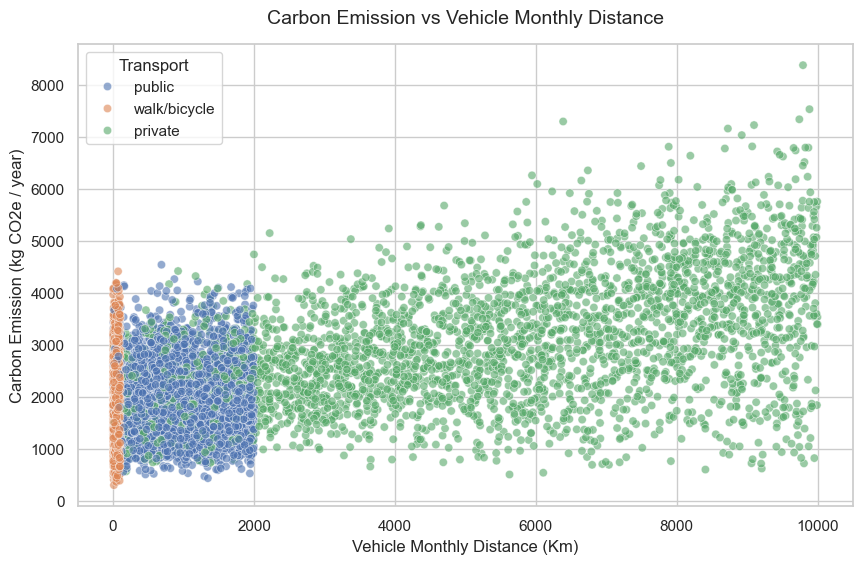

In [5]:
# 2. Vehicle Distance vs Carbon Emission by Transport Mode
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Vehicle Monthly Distance Km', y='CarbonEmission', hue='Transport', alpha=0.6)
plt.title('Carbon Emission vs Vehicle Monthly Distance', fontsize=14, pad=15)
plt.xlabel('Vehicle Monthly Distance (Km)', fontsize=12)
plt.ylabel('Carbon Emission (kg CO2e / year)', fontsize=12)
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19096\1869764524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Diet', y='CarbonEmission', palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19096\1869764524.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Frequency of Traveling by Air', y='CarbonEmission', palette='Set3')


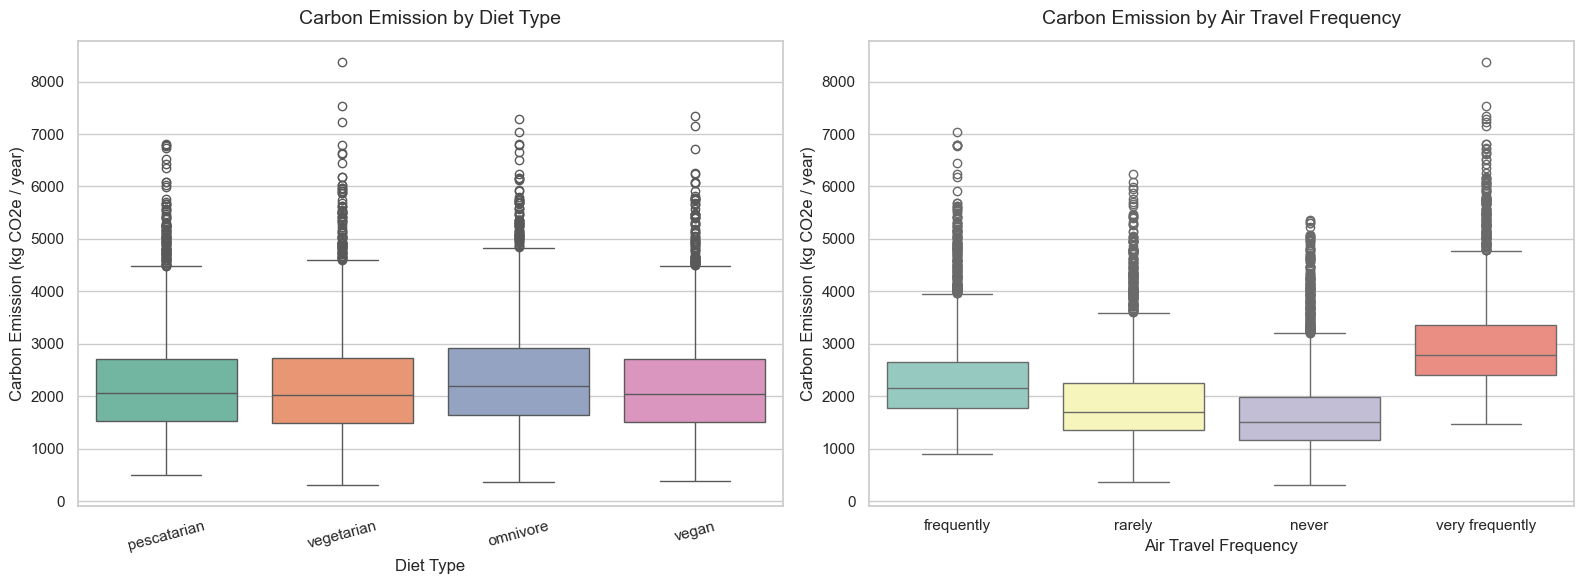

In [6]:
# 3. Carbon Emissions by Diet and Air Travel frequency
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df, x='Diet', y='CarbonEmission', palette='Set2')
axes[0].set_title('Carbon Emission by Diet Type', fontsize=14, pad=12)
axes[0].set_xlabel('Diet Type', fontsize=12)
axes[0].set_ylabel('Carbon Emission (kg CO2e / year)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(ax=axes[1], data=df, x='Frequency of Traveling by Air', y='CarbonEmission', palette='Set3')
axes[1].set_title('Carbon Emission by Air Travel Frequency', fontsize=14, pad=12)
axes[1].set_xlabel('Air Travel Frequency', fontsize=12)
axes[1].set_ylabel('Carbon Emission (kg CO2e / year)', fontsize=12)

plt.tight_layout()
plt.show()


## 4. Data Preprocessing & Categorical Encoding
To train machine learning models, we convert categorical string columns to numerical label encodings.


In [7]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
le_dict = {}
df_encoded = df.copy()

# Apply LabelEncoder to all categorical columns
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

print("Categorical Encoding Mapping:")
for col in cat_cols:
    print(f"  {col}: {list(le_dict[col].classes_)}")


Categorical Encoding Mapping:
  Body Type: ['normal', 'obese', 'overweight', 'underweight']
  Sex: ['female', 'male']
  Diet: ['omnivore', 'pescatarian', 'vegan', 'vegetarian']
  How Often Shower: ['daily', 'less frequently', 'more frequently', 'twice a day']
  Heating Energy Source: ['coal', 'electricity', 'natural gas', 'wood']
  Transport: ['private', 'public', 'walk/bicycle']
  Vehicle Type: ['diesel', 'electric', 'hybrid', 'lpg', 'none', 'petrol']
  Social Activity: ['never', 'often', 'sometimes']
  Frequency of Traveling by Air: ['frequently', 'never', 'rarely', 'very frequently']
  Waste Bag Size: ['extra large', 'large', 'medium', 'small']
  Energy efficiency: ['No', 'Sometimes', 'Yes']
  Recycling: ["['Glass', 'Metal']", "['Glass']", "['Metal']", "['Paper', 'Glass', 'Metal']", "['Paper', 'Glass']", "['Paper', 'Metal']", "['Paper', 'Plastic', 'Glass', 'Metal']", "['Paper', 'Plastic', 'Glass']", "['Paper', 'Plastic', 'Metal']", "['Paper', 'Plastic']", "['Paper']", "['Plastic', '

In [8]:
# Define Features and Target
X = df_encoded.drop('CarbonEmission', axis=1)
y = df_encoded['CarbonEmission']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (8000, 19)
Testing set size: (2000, 19)


## 5. Machine Learning Modeling & Comparison
We train three regression models and compare their metrics:
1. **Linear Regression (Baseline)**
2. **Random Forest Regressor (Ensemble)**
3. **HistGradientBoosting Regressor (Gradient Boosting)**


In [9]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

# Dictionary to save metrics and predictions
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        "model": model,
        "predictions": preds,
        "MSE": mse,
        "MAE": mae,
        "RMSE": np.sqrt(mse),
        "R2": r2
    }
    print(f"Successfully trained {name}")


Successfully trained Linear Regression


Successfully trained Random Forest


Successfully trained Hist Gradient Boosting


### Model Performance Evaluation


=== Model Comparison Metrics ===


,MAE (kg CO2e),RMSE (kg CO2e),R-squared (R2)
Linear Regression,524.1180,651.7279,0.5915
Random Forest,231.5778,309.8367,0.9077
Hist Gradient Boosting,117.4616,159.0347,0.9757


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19096\2434575263.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['R-squared (R2)'], palette='viridis')


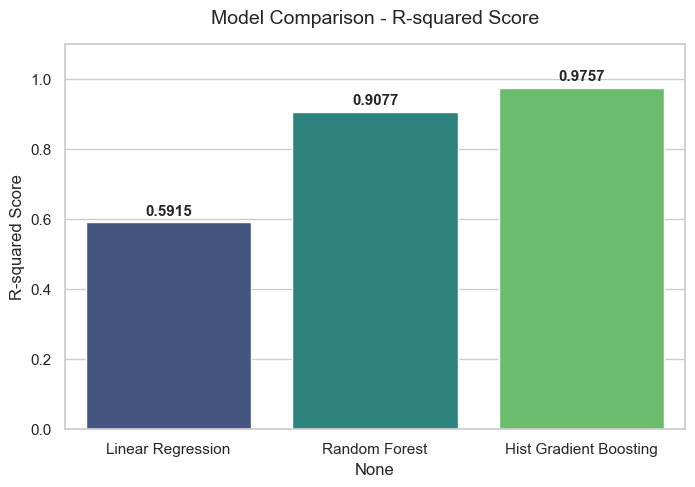

In [10]:
# Construct metrics comparison table
metrics_df = pd.DataFrame({
    name: {
        "MAE (kg CO2e)": res["MAE"],
        "RMSE (kg CO2e)": res["RMSE"],
        "R-squared (R2)": res["R2"]
    } for name, res in results.items()
}).T

# Format display
print("=== Model Comparison Metrics ===")
display(metrics_df.round(4))

# Barplot comparison of R2 scores
plt.figure(figsize=(8, 5))
sns.barplot(x=metrics_df.index, y=metrics_df['R-squared (R2)'], palette='viridis')
plt.title('Model Comparison - R-squared Score', fontsize=14, pad=15)
plt.ylabel('R-squared Score', fontsize=12)
plt.ylim(0, 1.1)
for i, val in enumerate(metrics_df['R-squared (R2)']):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', fontweight='bold', fontsize=11)
plt.show()


### Feature Importance and Predictions vs. Actuals
Let's see what features the Random Forest model prioritized, and inspect the correlation between true and predicted emissions for our best model, **HistGradientBoosting**.


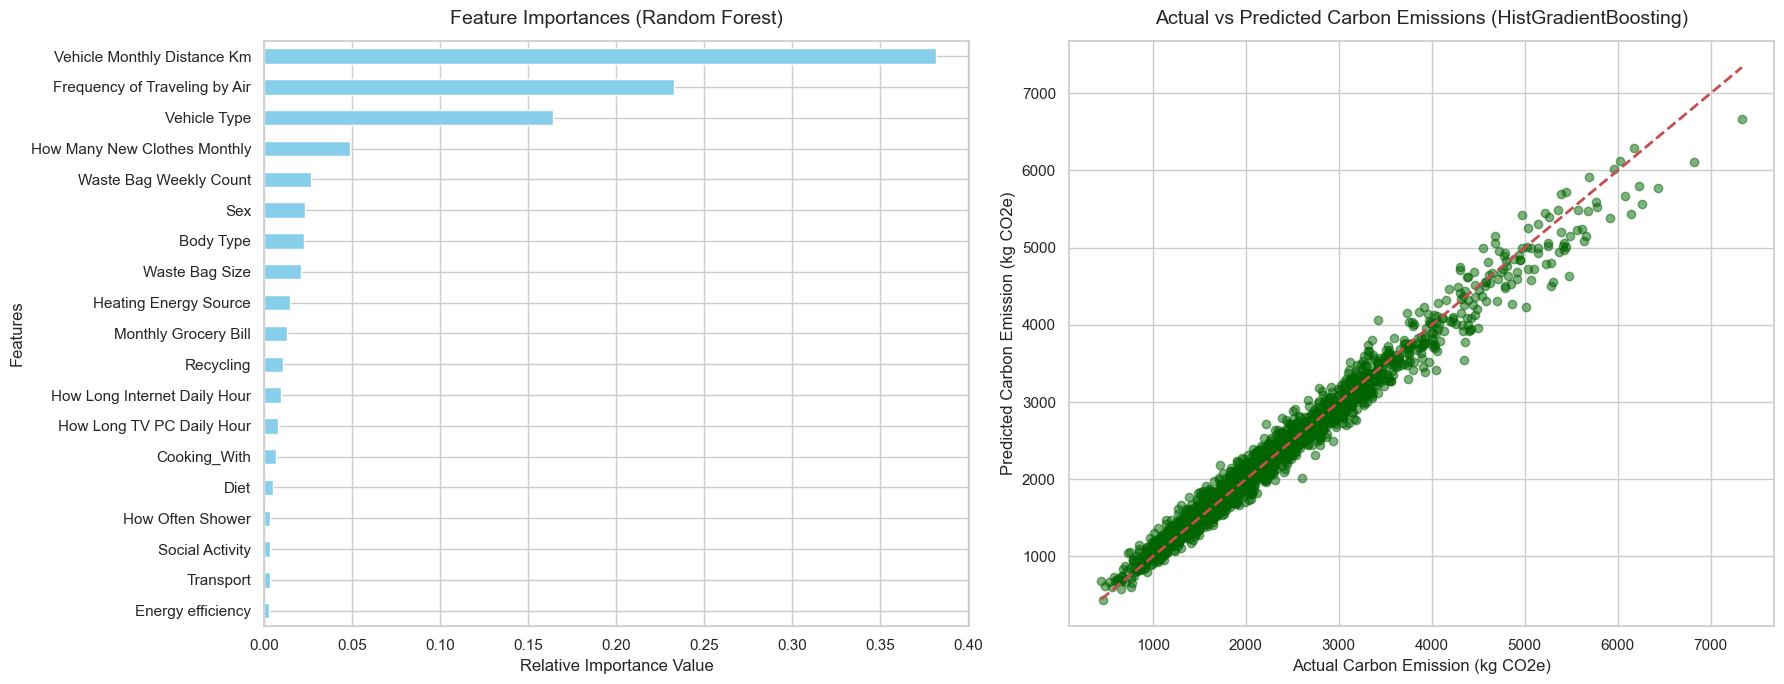

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Feature Importances (Random Forest)
rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Feature Importances (Random Forest)', fontsize=14, pad=12)
axes[0].set_xlabel('Relative Importance Value', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)

# 2. Actual vs Predicted Scatter plot
hgb_preds = results["Hist Gradient Boosting"]["predictions"]
axes[1].scatter(y_test, hgb_preds, alpha=0.5, color='darkgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Actual vs Predicted Carbon Emissions (HistGradientBoosting)', fontsize=14, pad=12)
axes[1].set_xlabel('Actual Carbon Emission (kg CO2e)', fontsize=12)
axes[1].set_ylabel('Predicted Carbon Emission (kg CO2e)', fontsize=12)

plt.tight_layout()
plt.show()


## 6. Personal Carbon Footprint Calculator
We create a helper function that takes personal variables (as a python dictionary), pre-processes the inputs using the fitted `LabelEncoder` labels, runs prediction using our best-performing `HistGradientBoostingRegressor` model, and returns customized advice on how to decrease carbon footprint.


In [12]:
def calculate_carbon_footprint(inputs):
    """
    Calculates carbon emissions and returns recommendations to reduce them.
    inputs: dict containing keys for all feature columns.
    """
    # Copy input data
    input_data = inputs.copy()
    
    # Process categorical values using fitted encoders
    for col, le in le_dict.items():
        val = input_data.get(col)
        # Handle cases where value isn't directly matching a known category class
        if val not in le.classes_:
            if 'none' in le.classes_:
                val = 'none'
            else:
                val = le.classes_[0]
        input_data[col] = le.transform([val])[0]
        
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Predict using the HistGradientBoosting model (R2 score ~ 0.976)
    best_model = results["Hist Gradient Boosting"]["model"]
    predicted_emission = best_model.predict(input_df)[0]
    
    # Display Results
    print("="*60)
    print("         PERSONAL CARBON FOOTPRINT CALCULATOR SUMMARY")
    print("="*60)
    print(f"Predicted Annual Carbon Footprint: {predicted_emission:.2f} kg CO2e / year")
    print("-"*60)
    
    # Personalized Recommendations
    print("Tailored Sustainability Recommendations:")
    recommendations = []
    
    # 1. Diet Recommendation
    if inputs['Diet'] in ['omnivore']:
        recommendations.append("- Diet: Shift towards a pescatarian, vegetarian, or vegan diet, or reduce red meat consumption. Livestock farming represents a major greenhouse gas source.")
    
    # 2. Transportation Recommendation
    if inputs['Transport'] == 'private' and inputs['Vehicle Type'] in ['petrol', 'diesel', 'lpg']:
        recommendations.append(f"- Transportation: Your private vehicle runs on {inputs['Vehicle Type']}. Shifting to hybrid/electric vehicles, or carpooling/biking, will substantially reduce carbon output.")
    if inputs['Vehicle Monthly Distance Km'] > 1200:
        recommendations.append(f"- Travel: With {inputs['Vehicle Monthly Distance Km']} km driven monthly, plan fewer, more consolidated trips, or use remote communication where possible.")
        
    # 3. Aviation Recommendation
    if inputs['Frequency of Traveling by Air'] in ['frequently', 'very frequently']:
        recommendations.append("- Aviation: Frequent air travel has a high emissions density per passenger mile. Consider taking fewer flights or looking into high-speed rail options.")
        
    # 4. Energy & Heating Recommendation
    if inputs['Heating Energy Source'] in ['coal', 'wood']:
        recommendations.append(f"- Heating: Using {inputs['Heating Energy Source']} as an energy source is highly emissions-heavy. Transition to natural gas, heat pumps, or renewable electrical sources.")
        
    # 5. Shopping habits
    if inputs['How Many New Clothes Monthly'] > 4:
        recommendations.append(f"- Consumption: Purchasing {inputs['How Many New Clothes Monthly']} new clothing items monthly contributes to fashion waste. Try purchasing second-hand or buying durable clothing.")
        
    # 6. Waste Recycling
    is_recycling = False
    try:
        items = eval(inputs['Recycling']) if isinstance(inputs['Recycling'], str) else inputs['Recycling']
        if isinstance(items, list) and len(items) > 0:
            is_recycling = True
    except:
        if inputs['Recycling'] != 'No':
            is_recycling = True
            
    if not is_recycling:
        recommendations.append("- Waste: Start sorting and recycling household waste (Plastic, Glass, Paper, Metal) to minimize landfill emissions.")
        
    if not recommendations:
        recommendations.append("- Excellent job! You are already practicing outstanding carbon-reduction habits. Keep it up!")
        
    for rec in recommendations:
        print(rec)
    print("="*60)
    return predicted_emission

# Define a sample profile
sample_profile = {
    'Body Type': 'normal',
    'Sex': 'female',
    'Diet': 'omnivore',
    'How Often Shower': 'daily',
    'Heating Energy Source': 'natural gas',
    'Transport': 'private',
    'Vehicle Type': 'petrol',
    'Social Activity': 'sometimes',
    'Monthly Grocery Bill': 120,
    'Frequency of Traveling by Air': 'rarely',
    'Vehicle Monthly Distance Km': 1000,
    'Waste Bag Size': 'medium',
    'Waste Bag Weekly Count': 2,
    'How Long TV PC Daily Hour': 3,
    'How Many New Clothes Monthly': 2,
    'How Long Internet Daily Hour': 4,
    'Energy efficiency': 'Yes',
    'Recycling': "['Paper', 'Plastic']",
    'Cooking_With': "['Stove', 'Microwave']"
}

# Run the calculator
_ = calculate_carbon_footprint(sample_profile)


         PERSONAL CARBON FOOTPRINT CALCULATOR SUMMARY
Predicted Annual Carbon Footprint: 1102.77 kg CO2e / year
------------------------------------------------------------
Tailored Sustainability Recommendations:
- Diet: Shift towards a pescatarian, vegetarian, or vegan diet, or reduce red meat consumption. Livestock farming represents a major greenhouse gas source.
- Transportation: Your private vehicle runs on petrol. Shifting to hybrid/electric vehicles, or carpooling/biking, will substantially reduce carbon output.


## 7. Conclusions
- **Best Performing Model**: HistGradientBoosting Regressor achieved an $R^2$ score of **~97.57%**, making it an exceptionally strong predictor of personal carbon footprints.
- **Top Emission Drivers**: `Vehicle Monthly Distance Km`, `Frequency of Traveling by Air`, and `Vehicle Type` are the top drivers of individual carbon footprint, followed by shopping habits (`How Many New Clothes Monthly`).
- **Application**: The predictive calculator function can be integrated into consumer-facing applications to estimate personal impact and provide actionable mitigation suggestions. This completes our green internship analysis!
